# PyStructure — example analysis notebook

This notebook demonstrates how to load a PyStructure `.ecsv` database and make basic plots.

**Requirements:** `pystructurePipeline` installed in your environment (`pip install -e .` from the repo root).

**Before running:** set `ECSV_FILE` in the cell below to point at your output file.

In [1]:
import sys
sys.path.insert(0, "..")   # so pystructureAnalysis.py is found when notebook is in analysis/

import numpy as np
import matplotlib.pyplot as plt

from pystructureAnalysis import pystructureAnalysis

# -----------------------------------------------------------------
# USER SETTING: path to your .ecsv output file
# -----------------------------------------------------------------
ECSV_FILE = "../output/ngc5194_data_struct_27as_2026_06_22.ecsv"

ps = pystructureAnalysis(ECSV_FILE)
print(ps)

pystructureAnalysis(source='ngc5194', n_pts=939, lines=['12CO21', '12CO10'])


## 1 — Inspect the database

The underlying Astropy Table is accessible as `ps.struct`.

In [2]:
print("Source:      ", ps.struct.meta.get("Source"))
print("N sampling points:", len(ps.struct))
print("Lines found: ", ps.lines)
print()
print("All columns:")
for col in ps.struct.colnames:
    print(f"  {col}")

Source:       ngc5194
N sampling points: 939
Lines found:  ['12CO21', '12CO10']

All columns:
  ra_deg
  dec_deg
  rgal_as
  rgal_kpc
  rgal_r25
  theta_rad
  MAP_SPIRE250
  SPEC_12CO21
  SPEC_12CO10
  SPEC_MASK_12CO21
  SPEC_MASK
  SPEC_VAXIS
  SPEC_VAXISSHUFF
  MOM0_12CO21
  EMOM0_12CO21
  TPEAK_12CO21
  RMS_12CO21
  MOM1_12CO21
  EMOM1_12CO21
  MOM2_12CO21
  EMOM2_12CO21
  EW_12CO21
  EEW_12CO21
  SPEC_SHUFF12CO21
  MOM0_12CO10
  EMOM0_12CO10
  TPEAK_12CO10
  RMS_12CO10
  MOM1_12CO10
  EMOM1_12CO10
  MOM2_12CO10
  EMOM2_12CO10
  EW_12CO10
  EEW_12CO10
  SPEC_SHUFF12CO10


## 2 — Moment-0 map

Plot the integrated intensity map for the first spectral line.

Plotting MOM0 for: 12CO21


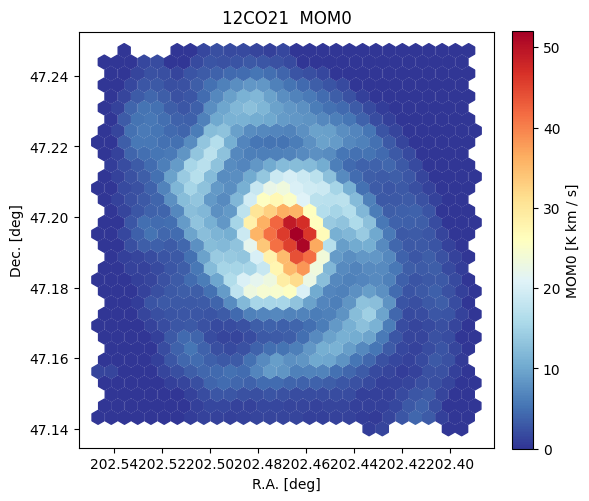

In [3]:
line = ps.lines[0]   # e.g. "12CO21"
print(f"Plotting MOM0 for: {line}")

ps.quickplot_map(line, quantity="MOM0", cmap="RdYlBu_r", stretch="lin")

### 2a — Same map in offset coordinates

Pass the source centre as an RA/Dec string to switch to arcsecond offsets.

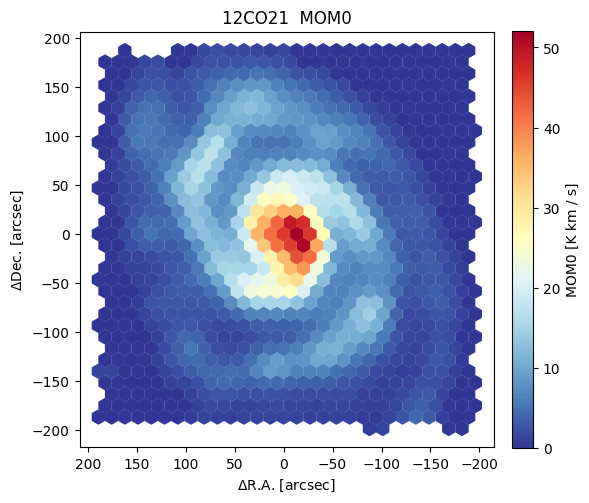

In [7]:
# Adjust centre coordinates to match your source
CENTER = "13:29:52.7 +47:11:43"   # NGC 5194 (M51a)

ps.quickplot_map(line, quantity="MOM0", center=CENTER, cmap="RdYlBu_r")

### 2b — Peak brightness map

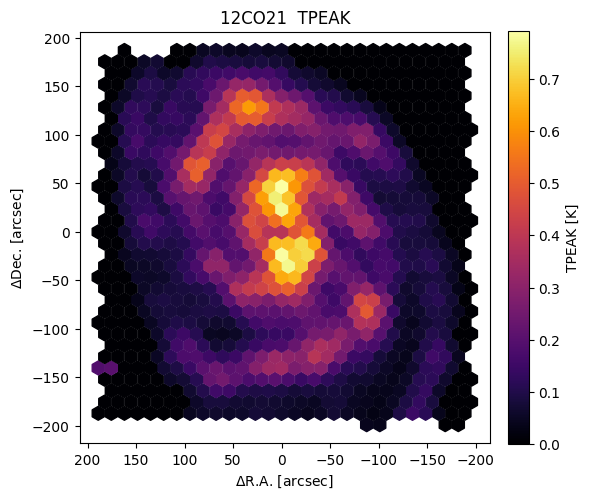

In [8]:
ps.quickplot_map(line, quantity="TPEAK", center=CENTER, cmap="inferno", stretch="lin")

## 3 — Moment-1 (mean velocity) map

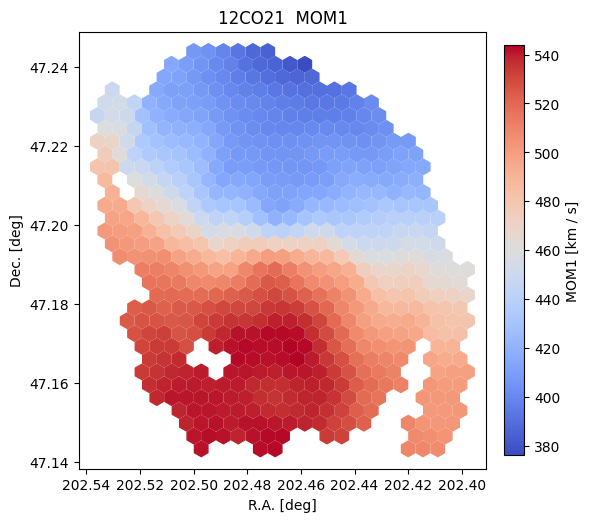

In [11]:
ps.quickplot_map(line, quantity="MOM1", cmap="coolwarm", stretch="lin", s=125)

## 4 — Individual spectrum

Plot the spectrum at the sampling point closest to the source centre.
The shaded region shows the integration mask.

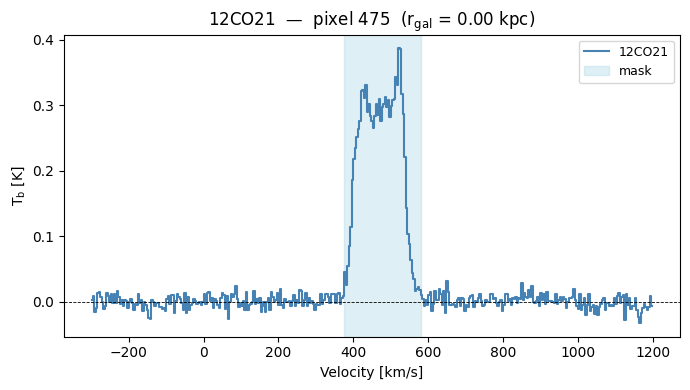

In [12]:
ps.quickplot_spectrum(line, show_mask=True)

### 4a — Spectrum at a specific pixel index

Brightest pixel index: 474  (rgal = 0.61 kpc)


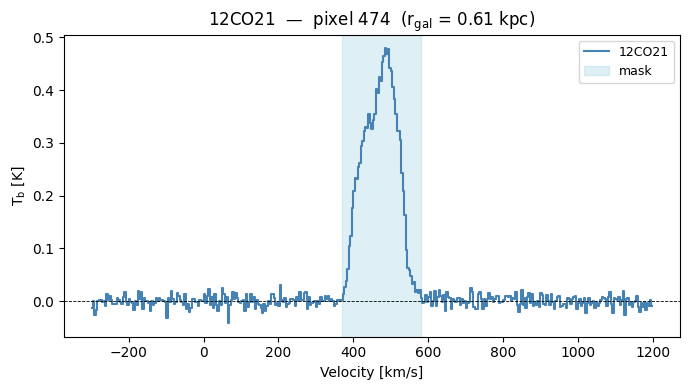

In [13]:
# Pick any index, e.g. a pixel with strong emission
mom0 = ps.get_mom0(line)
bright_idx = int(np.nanargmax(mom0))
print(f"Brightest pixel index: {bright_idx}  (rgal = {ps.rgal[bright_idx]:.2f} kpc)")

ps.quickplot_spectrum(line, idx=bright_idx, show_mask=True)

## 5 — Shuffled (velocity-shifted) spectrum

The shuffled spectrum has been shifted so the emission is centred at v = 0.

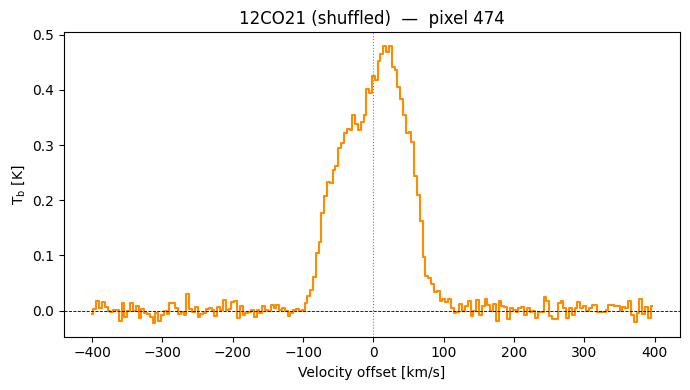

In [14]:
ps.quickplot_shuffled_spectrum(line, idx=bright_idx)

## 6 — Radial profile

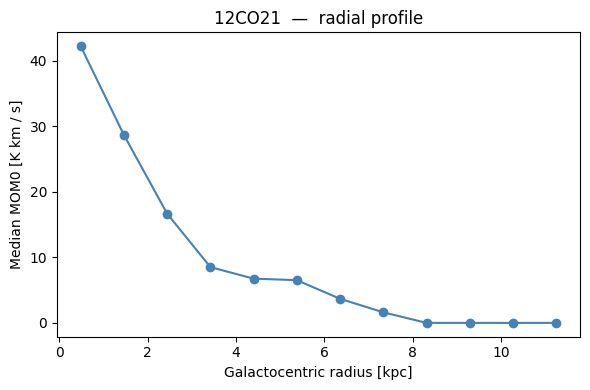

In [15]:
ps.quickplot_radial_profile(line, quantity="MOM0", nbins=12)

## 7 — Multi-panel overview

Combine several plots into one figure.

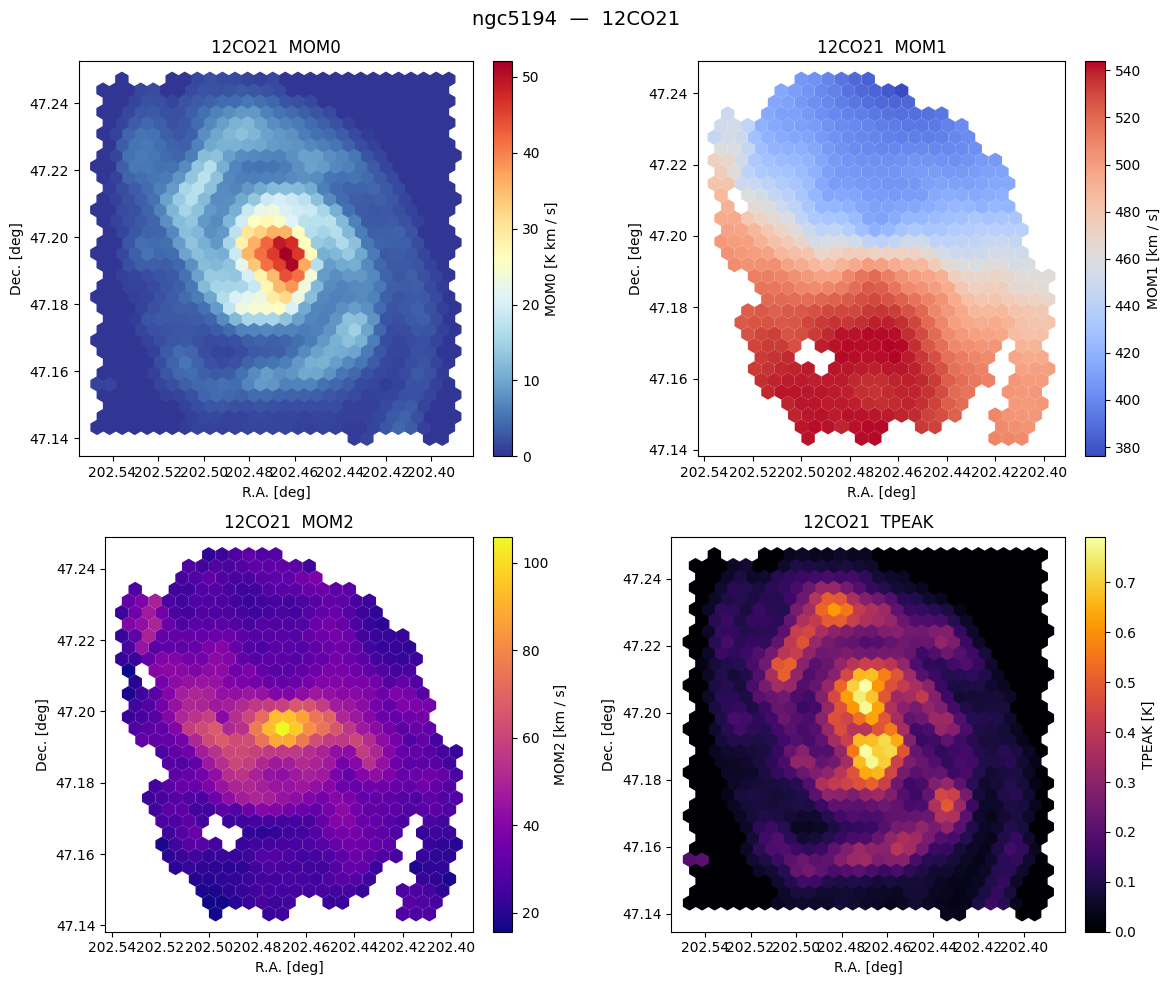

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ps.quickplot_map(line, quantity="MOM0",  ax=axes[0, 0])
ps.quickplot_map(line, quantity="MOM1",  ax=axes[0, 1], cmap="coolwarm")
ps.quickplot_map(line, quantity="MOM2",  ax=axes[1, 0], cmap="plasma")
ps.quickplot_map(line, quantity="TPEAK", ax=axes[1, 1], cmap="inferno")

fig.suptitle(f"{ps.struct.meta.get('Source', '')}  —  {line}", fontsize=14)
plt.tight_layout()
plt.show()

## 8 — Line ratio (if two lines are available)

Skip this cell if only one line is in the database.

Computing ratio: 12CO21 / 12CO10


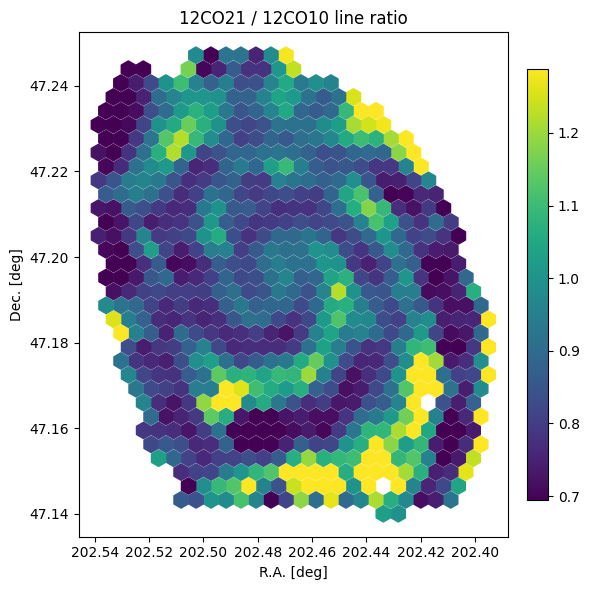

In [21]:
import matplotlib.colors as mcolors
if len(ps.lines) >= 2:
    line1, line2 = ps.lines[0], ps.lines[1]
    print(f"Computing ratio: {line1} / {line2}")

    ratio = ps.get_ratio(line1, line2, sn=5)
    r = ratio["ratio"]

    ra, dec = ps.get_coordinates()
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.scatter(ra, dec, c=r, s=140, marker="h",
                    cmap="viridis",
                    norm=mcolors.Normalize(vmin=np.nanpercentile(r, 5),
                                           vmax=np.nanpercentile(r, 95)))
    ax.invert_xaxis()
    ax.set_xlabel("R.A. [deg]")
    ax.set_ylabel("Dec. [deg]")
    ax.set_title(f"{line1} / {line2} line ratio")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
else:
    print("Only one line in database — skipping ratio plot.")

## 9 — Export a 2D-only table (no spectra)

Useful for sharing or downstream analysis when you don't need the full spectra.

In [14]:
tbl_2d = ps.get_2D_database(save=False)
print("2D table columns:")
for col in tbl_2d.colnames:
    print(f"  {col}")

2D table columns:
  ra_deg
  dec_deg
  rgal_as
  rgal_kpc
  rgal_r25
  theta_rad
  MAP_SPIRE250
  MOM0_12CO21
  EMOM0_12CO21
  TPEAK_12CO21
  RMS_12CO21
  MOM1_12CO21
  EMOM1_12CO21
  MOM2_12CO21
  EMOM2_12CO21
  EW_12CO21
  EEW_12CO21
